In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("dataset/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.shape

(541909, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df.dropna(subset=["CustomerID", "Description"])

df.shape

(406829, 8)

In [6]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df.shape

(397884, 8)

In [7]:
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [8]:
df["TotalSales"].describe()

count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalSales, dtype: float64

In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [11]:
df["Year"] = df["InvoiceDate"].dt.year

df["Year"].value_counts().sort_index()

Year
2010     26157
2011    371727
Name: count, dtype: int64

In [12]:
df["Month"] = df["InvoiceDate"].dt.month

df["Month"].value_counts().sort_index()

Month
1     21229
2     19927
3     27175
4     22642
5     28320
6     27185
7     26825
8     27007
9     40028
10    49554
11    64531
12    43461
Name: count, dtype: int64

In [13]:
monthly_sales = df.groupby("Month")["TotalSales"].sum()

monthly_sales

Month
1      569445.040
2      447137.350
3      595500.760
4      469200.361
5      678594.560
6      661213.690
7      600091.011
8      645343.900
9      952838.382
10    1039318.790
11    1161817.380
12    1090906.680
Name: TotalSales, dtype: float64

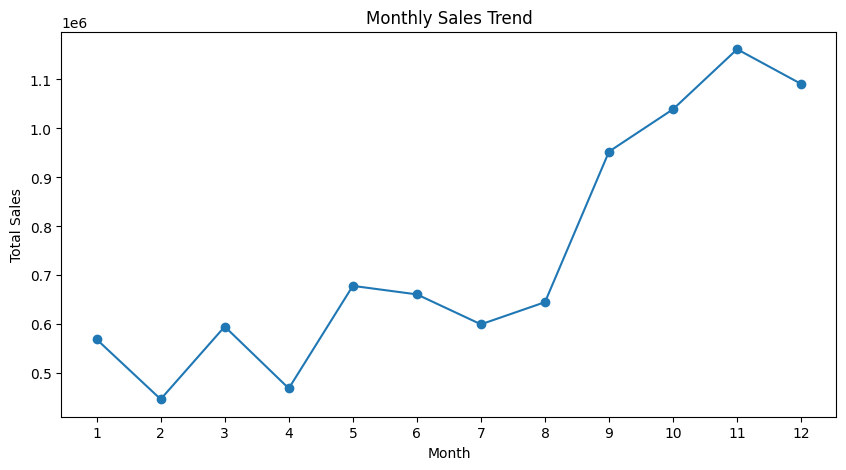

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))

plt.show()

In [15]:
yearly_sales = df.groupby("Year")["TotalSales"].sum()

yearly_sales

Year
2010     572713.890
2011    8338694.014
Name: TotalSales, dtype: float64

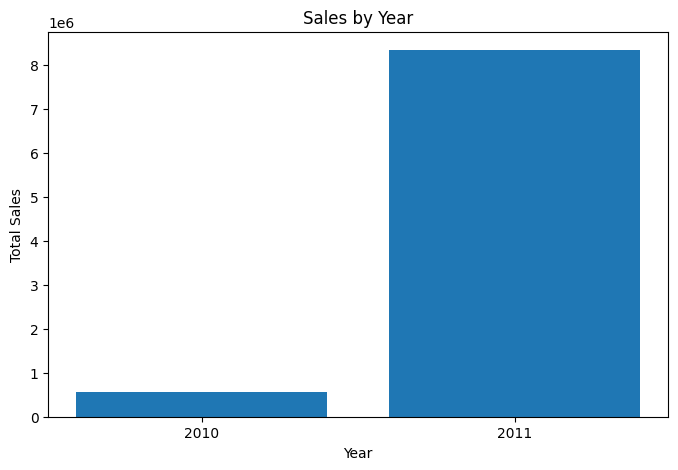

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(yearly_sales.index.astype(str), yearly_sales.values)

plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

In [17]:
country_sales = (
    df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalSales, dtype: float64

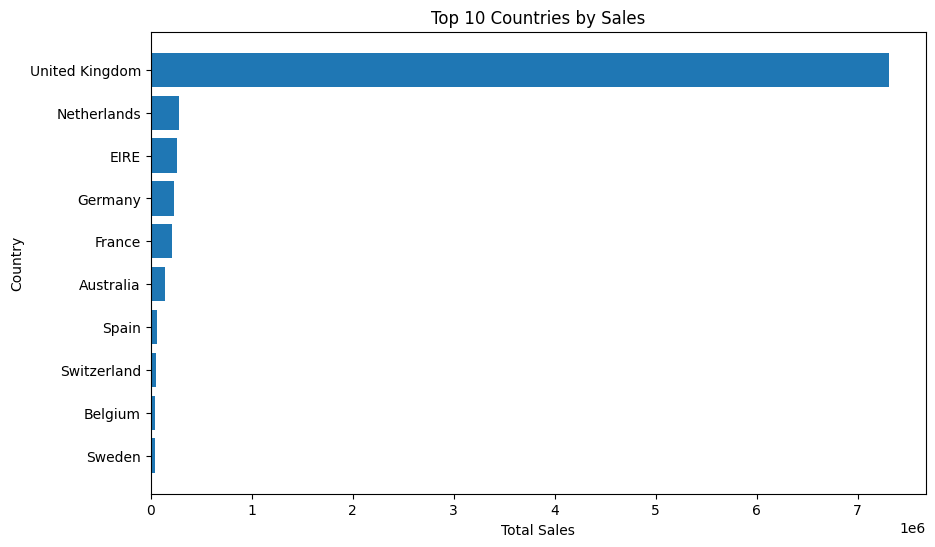

In [18]:
plt.figure(figsize=(10, 6))

plt.barh(country_sales.index[::-1], country_sales.values[::-1])

plt.title("Top 10 Countries by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.show()

In [19]:
product_sales = (
    df.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_sales

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: TotalSales, dtype: float64

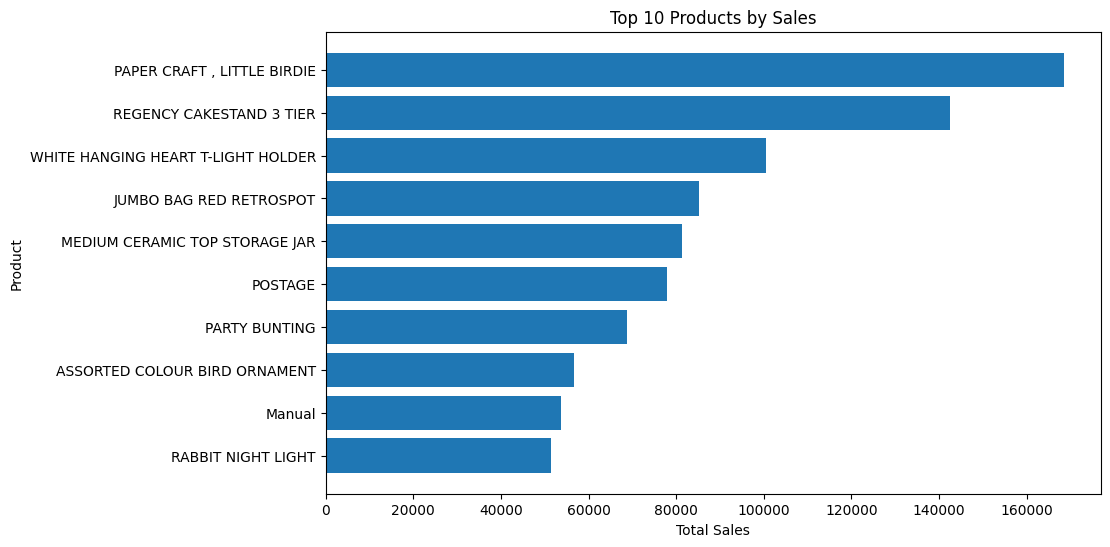

In [20]:
plt.figure(figsize=(10, 6))

plt.barh(product_sales.index[::-1], product_sales.values[::-1])

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

In [21]:
product_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

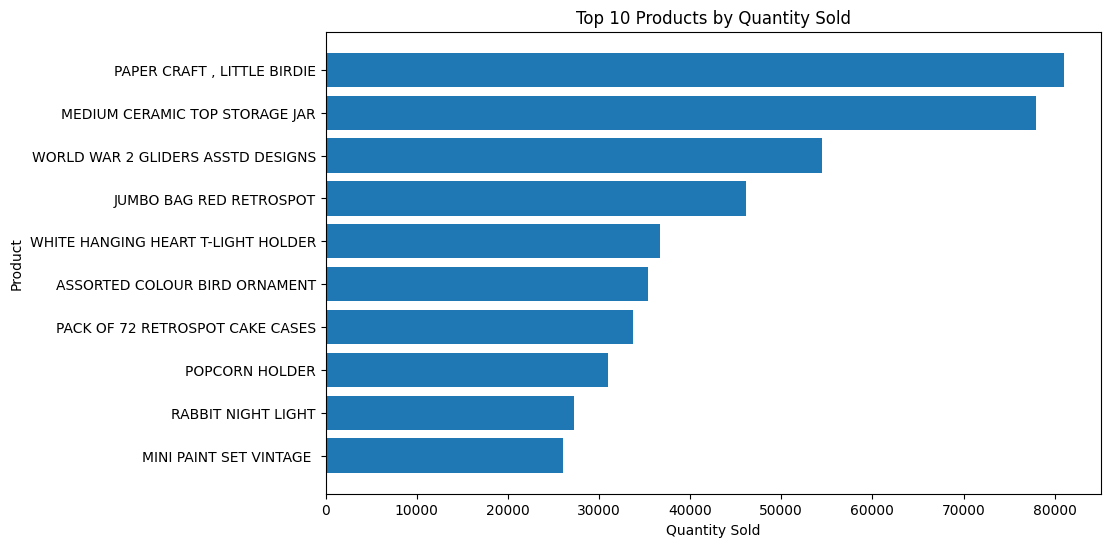

In [22]:
plt.figure(figsize=(10, 6))

plt.barh(product_quantity.index[::-1], product_quantity.values[::-1])

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

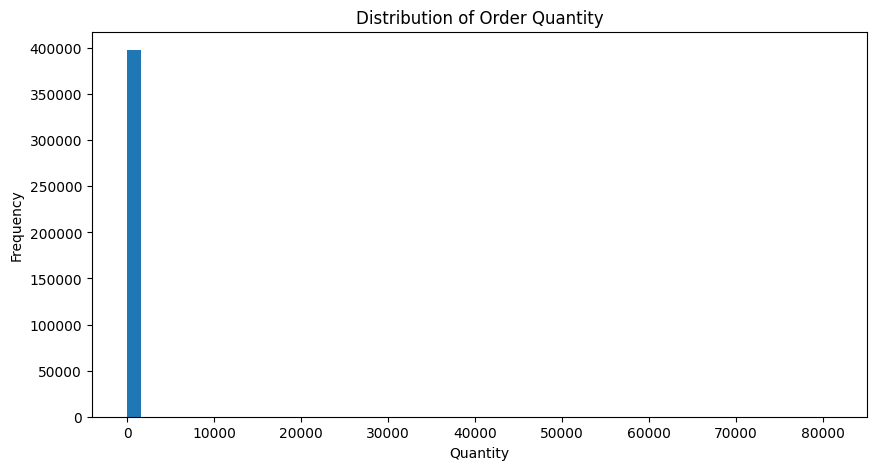

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(df["Quantity"], bins=50)

plt.title("Distribution of Order Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

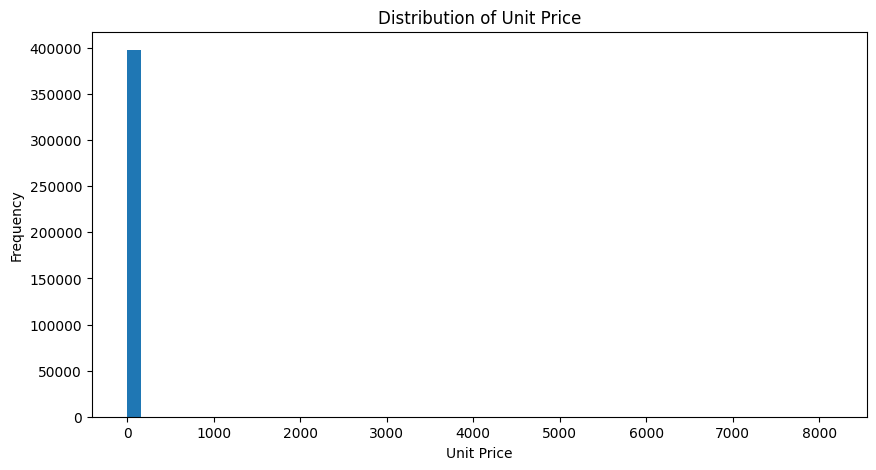

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(df["UnitPrice"], bins=50)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

In [25]:
customer_sales = (
    df.groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

customer_sales

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalSales, dtype: float64

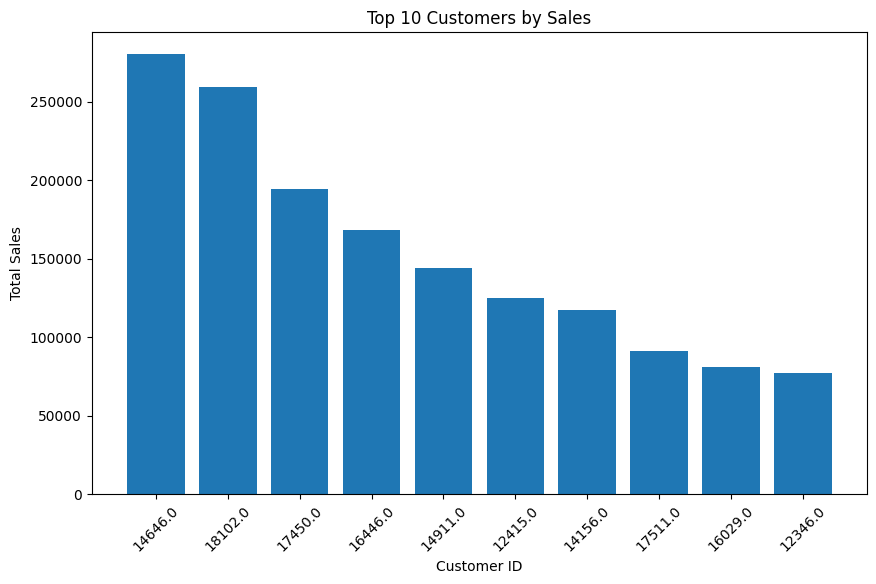

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    customer_sales.index.astype(str),
    customer_sales.values
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

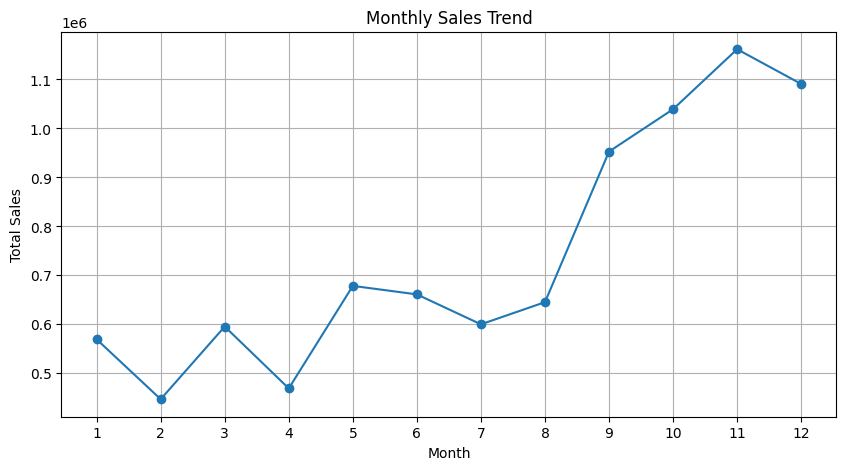

In [28]:
monthly_sales = df.groupby("Month")["TotalSales"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

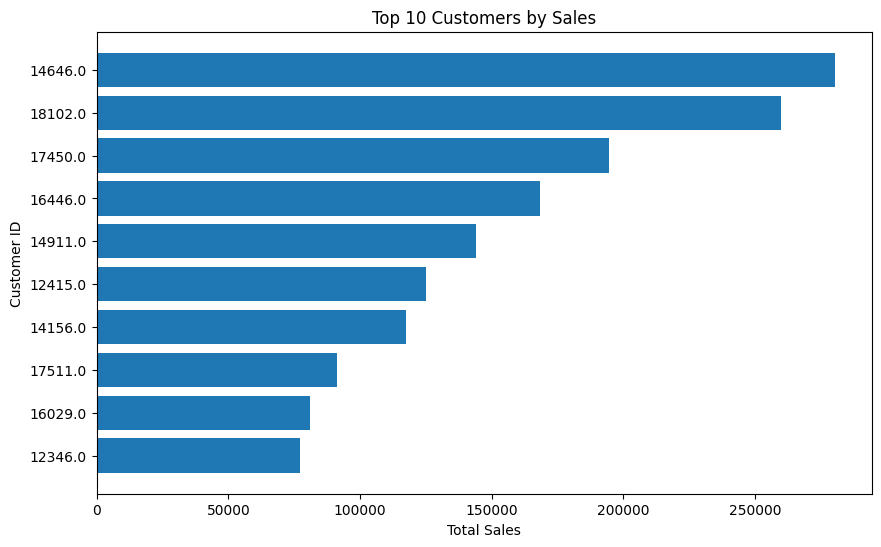

In [29]:
customer_sales = (
    df.groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    customer_sales.index.astype(str),
    customer_sales.values
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()
plt.show()

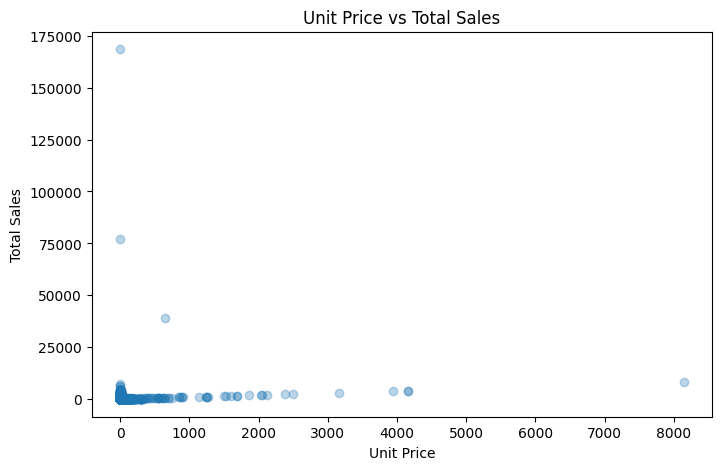

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["UnitPrice"],
    df["TotalSales"],
    alpha=0.3
)

plt.title("Unit Price vs Total Sales")
plt.xlabel("Unit Price")
plt.ylabel("Total Sales")

plt.show()

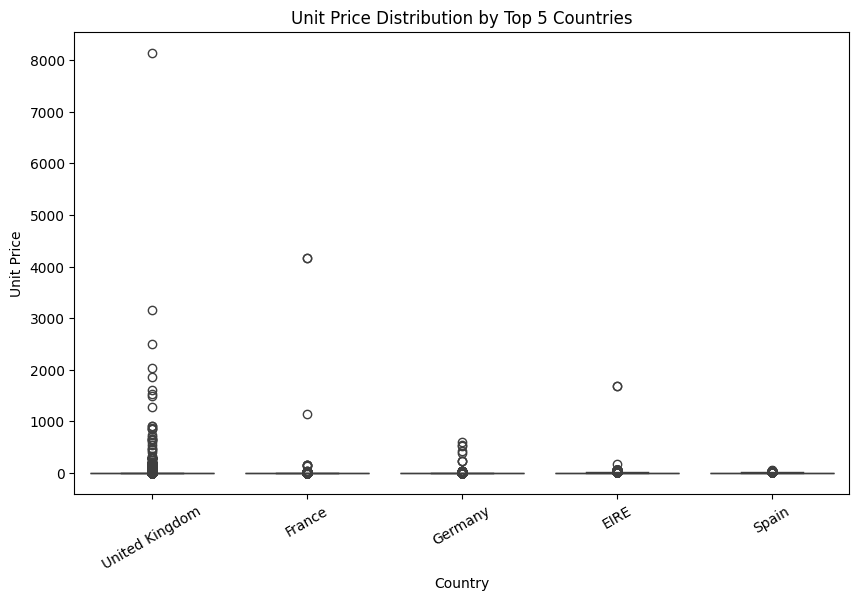

In [31]:
top5_countries = df["Country"].value_counts().head(5).index

plot_data = df[df["Country"].isin(top5_countries)]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_data,
    x="Country",
    y="UnitPrice"
)

plt.title("Unit Price Distribution by Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Unit Price")

plt.xticks(rotation=30)
plt.show()

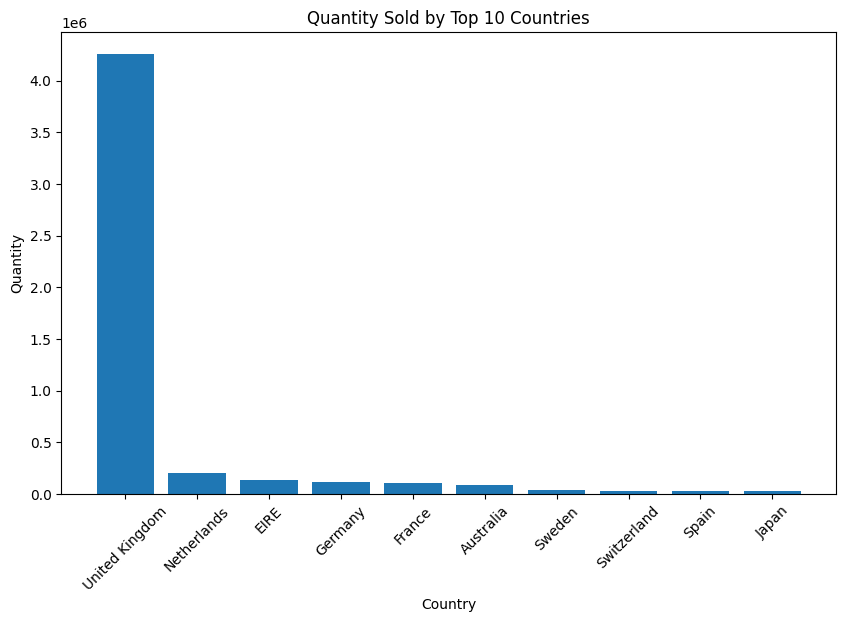

In [32]:
country_quantity = (
    df.groupby("Country")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    country_quantity.index,
    country_quantity.values
)

plt.title("Quantity Sold by Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Quantity")

plt.xticks(rotation=45)
plt.show()

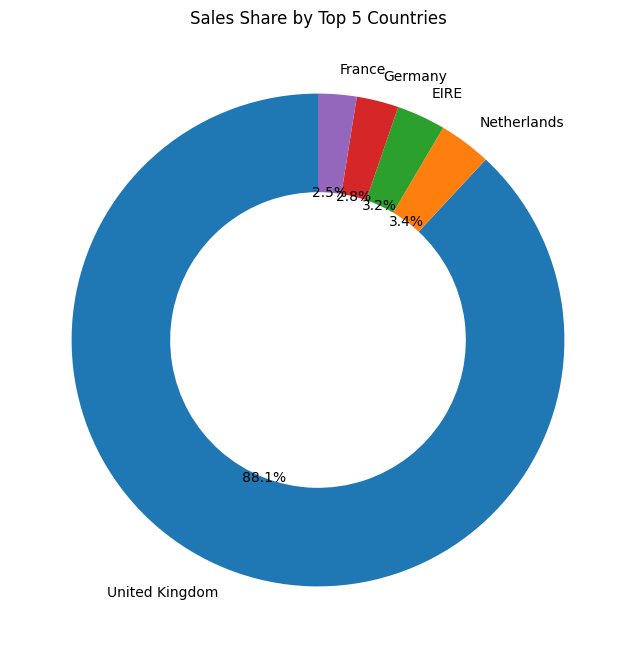

In [33]:
country_sales = (
    df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8, 8))

plt.pie(
    country_sales.values,
    labels=country_sales.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Sales Share by Top 5 Countries")

plt.show()

In [37]:
!pip install statsmodels


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from statsmodels.distributions.empirical_distribution import ECDF

data = df["UnitPrice"].dropna()

ecdf = ECDF(data)

plt.figure(figsize=(10, 5))

plt.plot(
    ecdf.x,
    ecdf.y
)

plt.title("ECDF of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Cumulative Probability")

plt.show()

ModuleNotFoundError: No module named 'statsmodels'

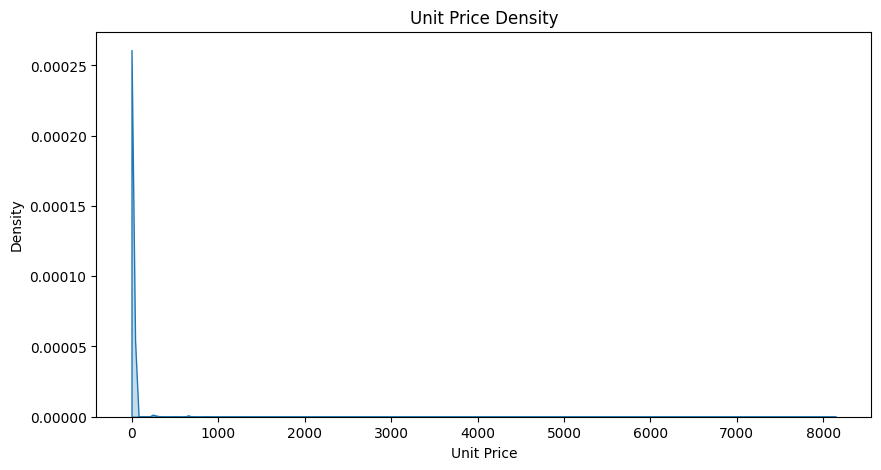

In [38]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    df["UnitPrice"].dropna(),
    fill=True
)

plt.title("Unit Price Density")
plt.xlabel("Unit Price")
plt.ylabel("Density")

plt.show()

In [27]:
total_sales = df["TotalSales"].sum()

total_quantity = df["Quantity"].sum()

total_transactions = df["InvoiceNo"].nunique()

total_customers = df["CustomerID"].nunique()

print("Total Sales:", total_sales)
print("Total Quantity Sold:", total_quantity)
print("Total Transactions:", total_transactions)
print("Total Customers:", total_customers)

Total Sales: 8911407.904
Total Quantity Sold: 5167812
Total Transactions: 18532
Total Customers: 4338
